In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import KBinsDiscretizer

In [65]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [66]:
df.dropna(inplace=True)
df.shape

(714, 3)

In [67]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


**Train-Test-Split**

In [68]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [69]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [70]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = (clf.predict(X_test))
acc_score1 = accuracy_score(y_test,y_pred)
print(f'Accuracy score : {acc_score1}')

Accuracy score : 0.6153846153846154


In [71]:
#cross val score
cross_val_score1 = np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))
print(f'Cross val score : {cross_val_score1}')

Cross val score : 0.6317097026604068


**KBinsDiscretizer = converts the numerical data into bins(categories)**

In [72]:
kbin_age = KBinsDiscretizer(n_bins=10,strategy='quantile',encode='ordinal')
kbin_fare = KBinsDiscretizer(n_bins=10,strategy='quantile',encode='ordinal')

In [73]:
#Colomn transformer
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [74]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [75]:
trf.named_transformers_['first']

KBinsDiscretizer(encode='ordinal', n_bins=10)

In [76]:
trf.named_transformers_['first'].n_bins

10

In [77]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [78]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.75  ,   7.8958,   9.225 ,  13.    ,  15.75  ,
               26.    ,  29.125 ,  51.4792,  82.1708, 512.3292])         ],
      dtype=object)

In [79]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]

})

In [80]:
# pd.cut() in Pandas is used when you want to convert continuous numerical data into discrete bins (categories).
output['age_labels'] = pd.cut(x=X_train['Age'],bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],bins=trf.named_transformers_['second'].bin_edges_[0].tolist())
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
278,7.0,0.0,29.1250,7.0,"(0.42, 14.0]","(26.0, 29.125]"
649,23.0,3.0,7.5500,0.0,"(22.0, 25.0]","(0.0, 7.75]"
106,21.0,2.0,7.6500,0.0,"(19.0, 22.0]","(0.0, 7.75]"
380,42.0,8.0,227.5250,9.0,"(36.0, 42.0]","(82.171, 512.329]"
202,34.0,6.0,6.4958,0.0,"(32.0, 36.0]","(0.0, 7.75]"


In [81]:
#decision tree algorithm
clf2 = DecisionTreeClassifier()
clf2.fit(X_train_trf,y_train)
y_pred2 = clf2.predict(X_test_trf)
acc_score2 = accuracy_score(y_test,y_pred2)
print(f'Accuracy score : {acc_score2}')

Accuracy score : 0.6223776223776224


In [82]:
X_trf = trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy'))

np.float64(0.682140062597809)

### **Algorithm with graphs to plot**

In [85]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Age Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("Age After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title("Fare Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare After")

    plt.show()

0.6331181533646322


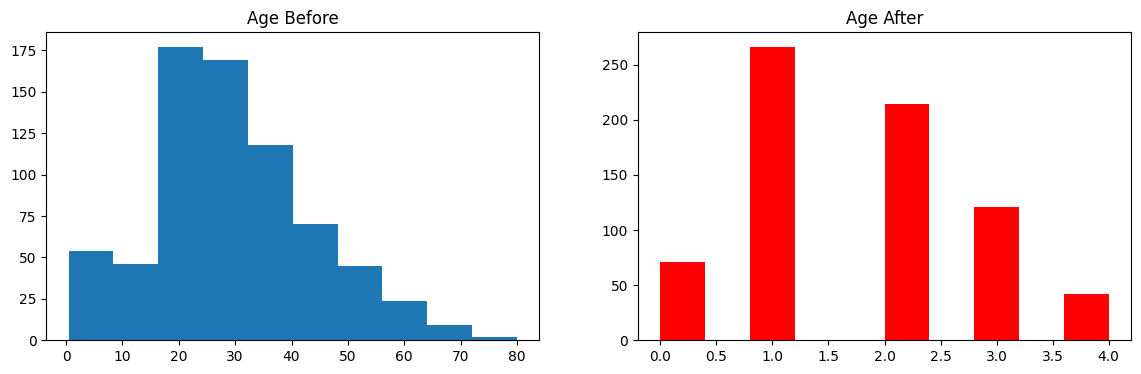

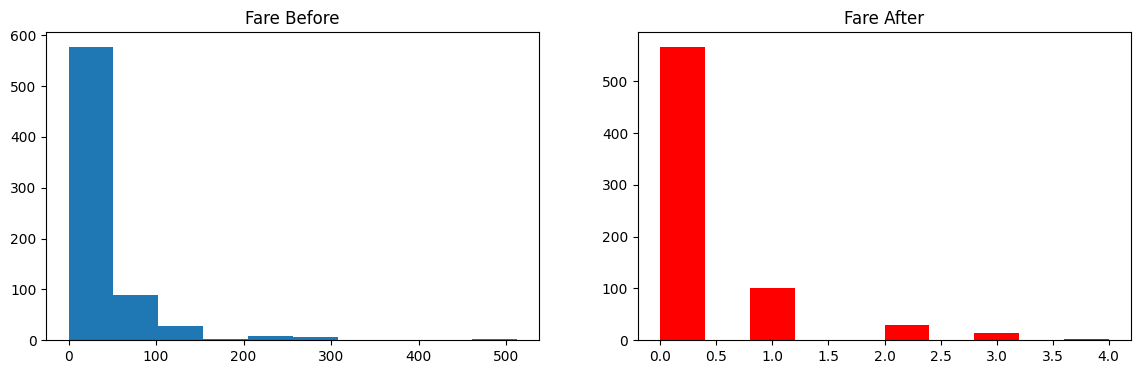

In [86]:
discretize(5,'kmeans')